# ML configuration cookbook

A renderer decides what shape a source becomes, and that choice is not free: it
determines whether samples can be stacked into a batch, what happens when a
source is absent for a position and date, and how much of the native resolution
survives. Each recipe below states the tensor structure it produces, what it
does with empty data, and why its renderer and collator fit that structure.
Every recipe runs against the same pinned catalog revision and the same
published evaluation QuerySet loaded in the setup cells, so the recipes differ
only in their rendering configuration.

In [1]:
import os
import warnings
from io import BytesIO
from pathlib import Path

from IPython.display import Image, display

# Hub transfers report progress on stderr, which would otherwise be captured as
# notebook output and rendered as noise in the documentation.
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

# Warnings raised by the library are part of what these tutorials demonstrate,
# but Python's default format prefixes each one with the absolute path of the
# file that raised it, which is an artifact of the machine that built the docs.
def _format_warning(message, category, filename, lineno, line=None):
    return f"{category.__name__}: {message}\n"

warnings.formatwarning = _format_warning

def display_figure(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=144, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))

PATCH_SIZE_KM = 256          # the published patch size
REQUESTED_ROWS = 4
SEED = 7

# Draw records are notebook output, not cached data; they land beside the notebook.
DRAW_DIR = Path("draws")
DRAW_DIR.mkdir(exist_ok=True)

In [2]:
from ocean_taco import CatalogConfig, QuerySet
from ocean_taco.retrieve import load_hf_dataset

config = CatalogConfig()
catalog = load_hf_dataset(config)
queryset = QuerySet.from_hub(PATCH_SIZE_KM, "eval")
print(f"queryset_id={queryset.queryset_id}; kind={queryset.header['kind']}; positions={len(queryset.positions)}; dates={len(queryset.dates)}")

queryset_id=2b55f024f45630d5a81546832a108ed99648c4d7b5024d79a21b1f0851ef4f18; kind=eval; positions=6027; dates=858


## Fixed grids and multimodal fusion

In [3]:
from ocean_taco.render import Native, Points, Resample, VectorPair
fixed = {"l4_sst": Resample((64, 64), .5), "l4_ssh": Resample((64, 64), .5)}
fusion = {**fixed, "l3_swot": Resample((64, 64), .5)}
print("layout: dense [T,H,W] per source; unavailable source has an empty structured payload")
print("fixed", fixed, "fusion", fusion)

layout: dense [T,H,W] per source; unavailable source has an empty structured payload
fixed {'l4_sst': Resample(shape=(64, 64), support_threshold=0.5, method='auto'), 'l4_ssh': Resample(shape=(64, 64), support_threshold=0.5, method='auto')} fusion {'l4_sst': Resample(shape=(64, 64), support_threshold=0.5, method='auto'), 'l4_ssh': Resample(shape=(64, 64), support_threshold=0.5, method='auto'), 'l3_swot': Resample(shape=(64, 64), support_threshold=0.5, method='auto')}


## Sparse/dense sources and vector pairs

In [4]:
sparse_dense = {"l4_sst": Resample((64, 64), .5), "l3_swot": Resample((64, 64), .5)}
vectors = {"velocity": VectorPair(Resample((64, 64), .5))}
print("Sparse SWOT keeps its own valid/support mask; do not treat missing cells as observations.")
print("VectorPair shares availability across eastward/northward components:", vectors["velocity"].components)

Sparse SWOT keeps its own valid/support mask; do not treat missing cells as observations.
VectorPair shares availability across eastward/northward components: ('glorys_uo', 'glorys_vo')


## Argo points

In [5]:
points = {"argo": Points(variable="TEMP", pres_range=(0, 10))}
print("layout: ragged records with lat/lon/pressure/profile IDs; zero points is a valid batch member.")
print(points)

layout: ragged records with lat/lon/pressure/profile IDs; zero points is a valid batch member.
{'argo': Points(pres_range=(0, 10), variable='TEMP')}


## Forecasting with two datasets

In [6]:
from ocean_taco import QueryFilter, draw_queryset
forecast = QueryFilter(relation="forecast", target_lead_days=1, context_start_offset_days=-1, context_end_offset_days=0)
draw = draw_queryset(queryset, requested_row_count=4, seed=19, record_path=DRAW_DIR / "forecast-draw.json", query_filter=forecast)
print(f"context/target draw rows={len(draw.rows)}; relation={forecast.relation}; lead={forecast.target_lead_days}d")
print("Use separate context and target datasets so a context model cannot accidentally consume the target.")

context/target draw rows=4; relation=forecast; lead=1d
Use separate context and target datasets so a context model cannot accidentally consume the target.


## Native shapes and bucketing

In [7]:
from ocean_taco.torch import ShapeBucketSampler
sampler = ShapeBucketSampler([(32, 48), (32, 48), (40, 48)], batch_size=2, seed=19)
print("Native keeps source shape; ShapeBucketSampler batches equal shapes:", list(sampler))
print("Use fixed Resample for ordinary dense fusion; use Native only when the model handles ragged resolution.")

Native keeps source shape; ShapeBucketSampler batches equal shapes: [[2], [1, 0]]
Use fixed Resample for ordinary dense fusion; use Native only when the model handles ragged resolution.


## Regional, antimeridian, leakage, and normalisation

In [8]:
from ocean_taco import GeoBox
import torch
regional = GeoBox(-80, -30, 10, 45)
wrapped = GeoBox(170, -170, 10, 30, wraps_antimeridian=True)
def normalise_valid(data, mask, mean, std):
    output = torch.full_like(data, float("nan")); output[mask] = (data[mask] - mean) / max(std, 1e-6); return output
print("regional", regional.to_dict(), "wrapped segments", [segment.to_dict() for segment in wrapped.segments()])
print("Leakage control: disjoint QuerySet filters, temporal guard bands, and persisted draw records.")
print("normalisation", normalise_valid(torch.tensor([1., float("nan"), 3.]), torch.tensor([True, False, True]), 2., 1.).tolist())

regional {'lon_min': -80, 'lon_max': -30, 'lat_min': 10, 'lat_max': 45, 'wraps_antimeridian': False} wrapped segments [{'lon_min': 170, 'lon_max': 180.0, 'lat_min': 10, 'lat_max': 30, 'wraps_antimeridian': False}, {'lon_min': -180.0, 'lon_max': -170, 'lat_min': 10, 'lat_max': 30, 'wraps_antimeridian': False}]
Leakage control: disjoint QuerySet filters, temporal guard bands, and persisted draw records.
normalisation [-1.0, nan, 1.0]


## Retrieved sample gallery

The following figures use the same recorded local draw as the recipes above. They show actual rendered values and their validity evidence, so the configuration choices can be inspected rather than inferred from object representations.

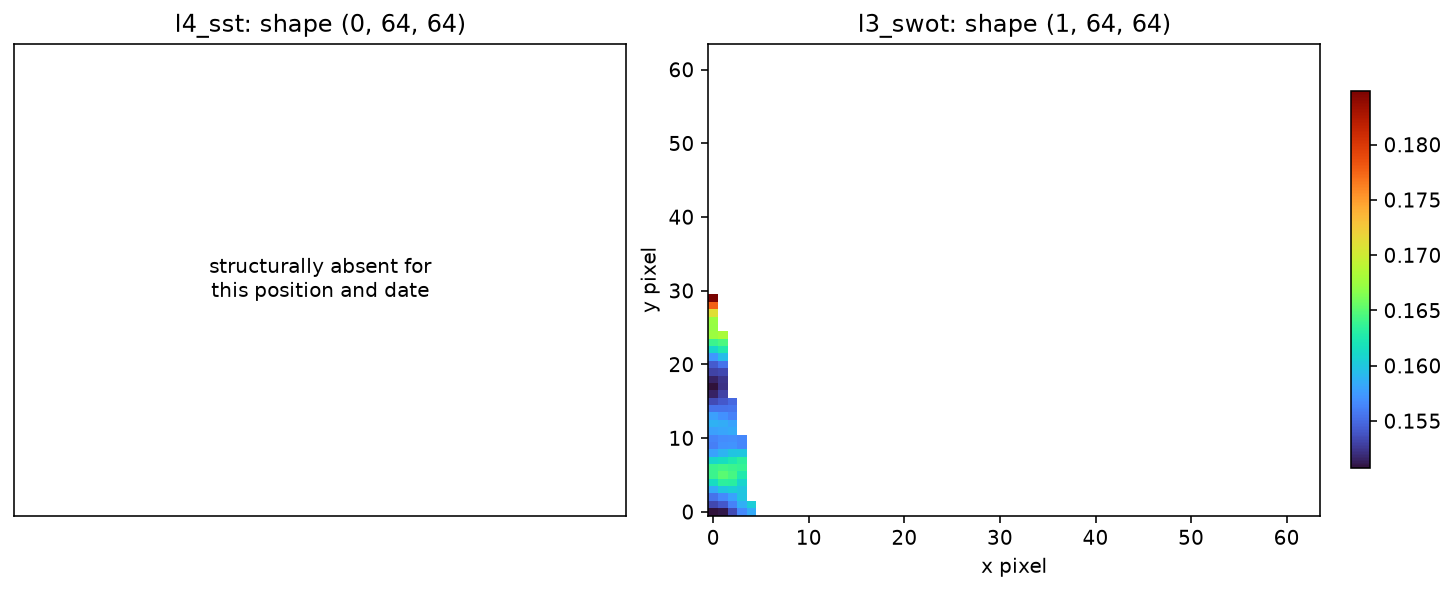

l4_sst data (0, 64, 64) valid_mask (0, 64, 64)
l3_swot data (1, 64, 64) valid_mask (1, 64, 64)
A source with no asset for this position and date renders with a leading zero dimension; the batch layout is unchanged.


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from ocean_taco import draw_queryset
from ocean_taco.render import Points, Resample
from ocean_taco.torch import OceanTACODataset
recipe_draw = draw_queryset(queryset, requested_row_count=1, seed=19, record_path=DRAW_DIR / "cookbook-draw.json")
recipe_dataset = OceanTACODataset(queries=recipe_draw, sources={"l4_sst": Resample((64, 64), .5), "l3_swot": Resample((64, 64), .5)}, catalog_config=config)
recipe_sample = recipe_dataset[0]

def show_grid(axis, record, title):
    # Draw a rendered source, or state its absence rather than inventing pixels.
    data = np.asarray(record["data"])
    if data.shape[0] == 0:
        axis.text(.5, .5, "structurally absent for\nthis position and date", ha="center", va="center", transform=axis.transAxes)
        axis.set(title=f"{title}: shape {data.shape}", xticks=[], yticks=[])
        return
    image = axis.imshow(data[0], origin="lower", cmap="turbo", aspect="auto")
    axis.set(title=f"{title}: shape {data.shape}", xlabel="x pixel", ylabel="y pixel")
    axis.figure.colorbar(image, ax=axis, shrink=.8)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for axis, token in zip(axes, ("l4_sst", "l3_swot")):
    show_grid(axis, recipe_sample[token], token)
from IPython.display import display
display_figure(fig)
for token in ("l4_sst", "l3_swot"):
    print(token, "data", np.asarray(recipe_sample[token]["data"]).shape, "valid_mask", np.asarray(recipe_sample[token]["valid_mask"]).shape)
print("A source with no asset for this position and date renders with a leading zero dimension; the batch layout is unchanged.")

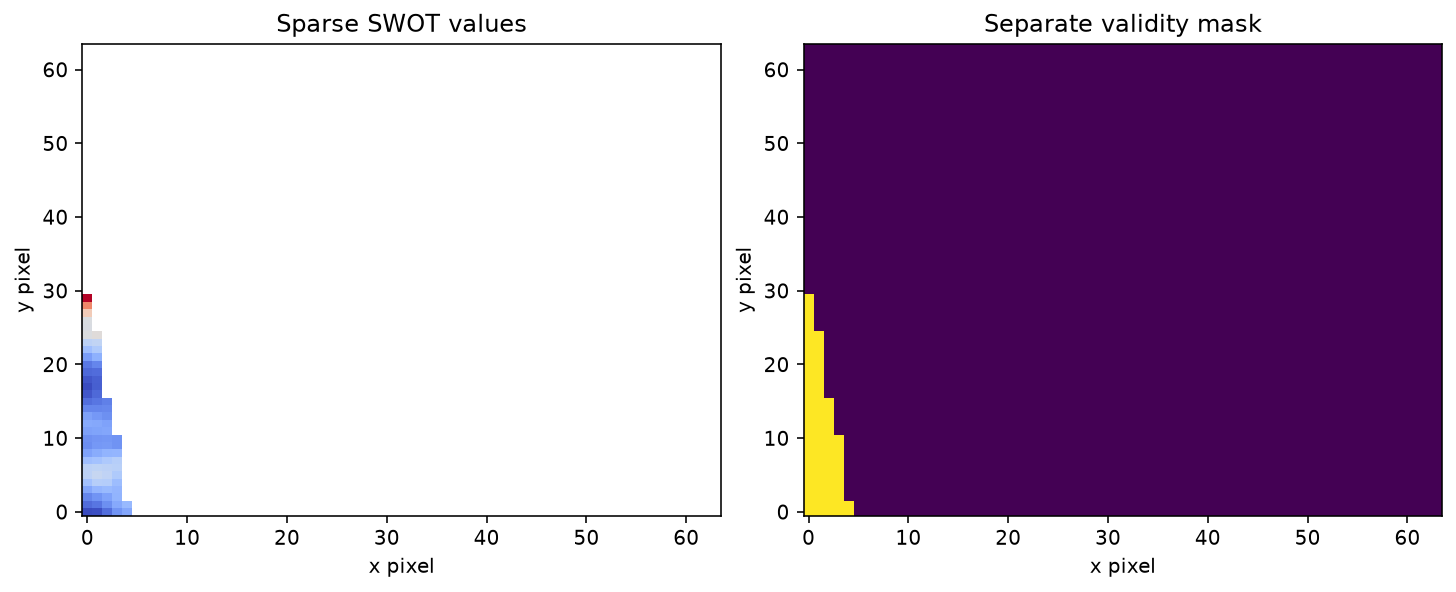

Sparse values and their validity evidence must travel together into the model.


In [10]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
axes[0].imshow(np.asarray(recipe_sample["l3_swot"]["data"])[0], origin="lower", cmap="coolwarm", aspect="auto")
axes[0].set(title="Sparse SWOT values", xlabel="x pixel", ylabel="y pixel")
axes[1].imshow(np.asarray(recipe_sample["l3_swot"]["valid_mask"])[0], origin="lower", cmap="viridis", vmin=0, vmax=1, aspect="auto")
axes[1].set(title="Separate validity mask", xlabel="x pixel", ylabel="y pixel")
from IPython.display import display
display_figure(fig)
print("Sparse values and their validity evidence must travel together into the model.")

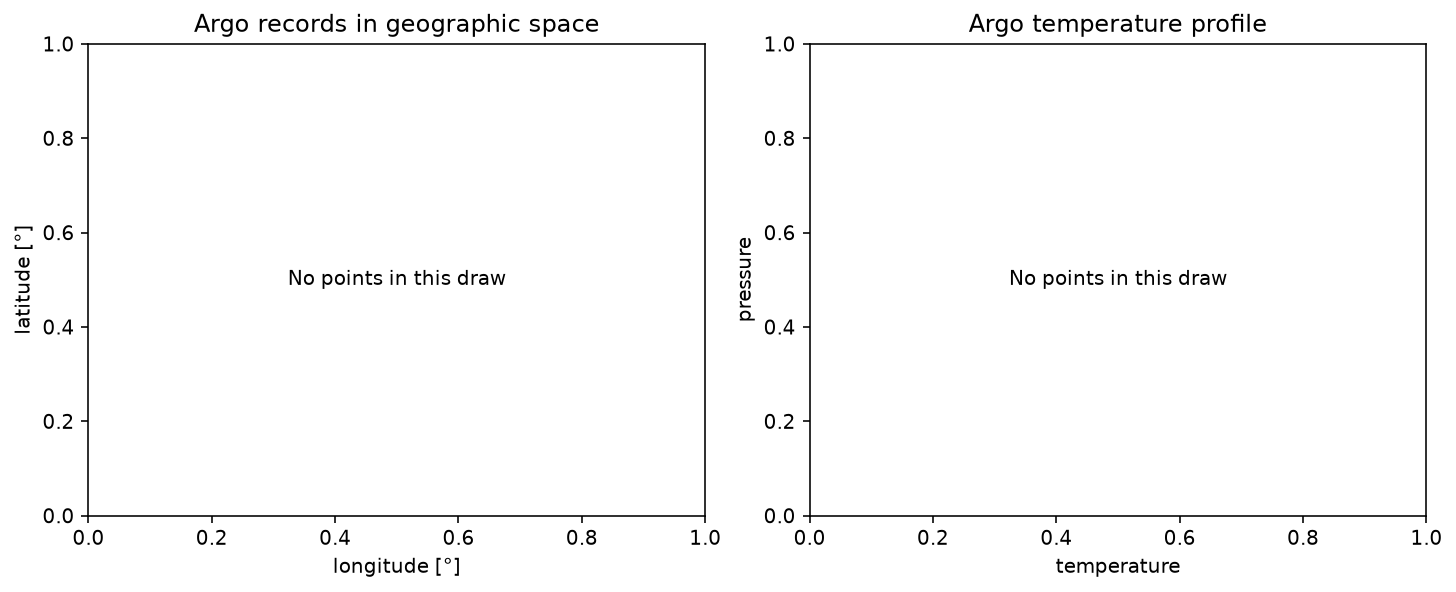

Ragged point data are visualised as records, not fabricated into a dense grid.


In [11]:
import matplotlib.pyplot as plt
argo_dataset = OceanTACODataset(queries=recipe_draw, sources={"argo": Points(variable="TEMP", pres_range=(0, 10))}, catalog_config=config)
argo_record = argo_dataset[0]["argo"]
data = np.asarray(argo_record["data"])
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
if data.size:
    axes[0].scatter(np.asarray(argo_record["lon"]), np.asarray(argo_record["lat"]), c=data, s=18, cmap="turbo")
    axes[1].scatter(data, np.asarray(argo_record["pres"]), s=18, color="#dd8a45")
    axes[1].invert_yaxis()
else:
    for axis in axes: axis.text(.5, .5, "No points in this draw", ha="center", va="center", transform=axis.transAxes)
axes[0].set(title="Argo records in geographic space", xlabel="longitude [°]", ylabel="latitude [°]")
axes[1].set(title="Argo temperature profile", xlabel="temperature", ylabel="pressure")
from IPython.display import display
display_figure(fig)
print("Ragged point data are visualised as records, not fabricated into a dense grid.")

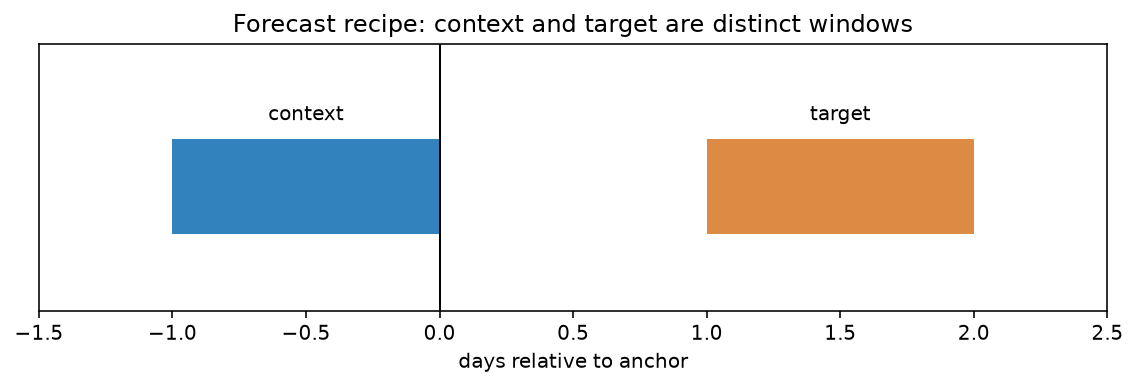

The timeline represents the QueryFilter relation used above, not an inferred observation schedule.


In [12]:
import matplotlib.pyplot as plt
fig, axis = plt.subplots(figsize=(8, 2.8))
axis.broken_barh([(-1, 1), (1, 1)], (4, 5), facecolors=["#3182bd", "#dd8a45"])
axis.axvline(0, color="black", lw=1)
axis.set(xlim=(-1.5, 2.5), ylim=(0, 14), yticks=[], xlabel="days relative to anchor", title="Forecast recipe: context and target are distinct windows")
axis.text(-.5, 10, "context", ha="center"); axis.text(1.5, 10, "target", ha="center")
fig.tight_layout()
from IPython.display import display
display_figure(fig)
print("The timeline represents the QueryFilter relation used above, not an inferred observation schedule.")

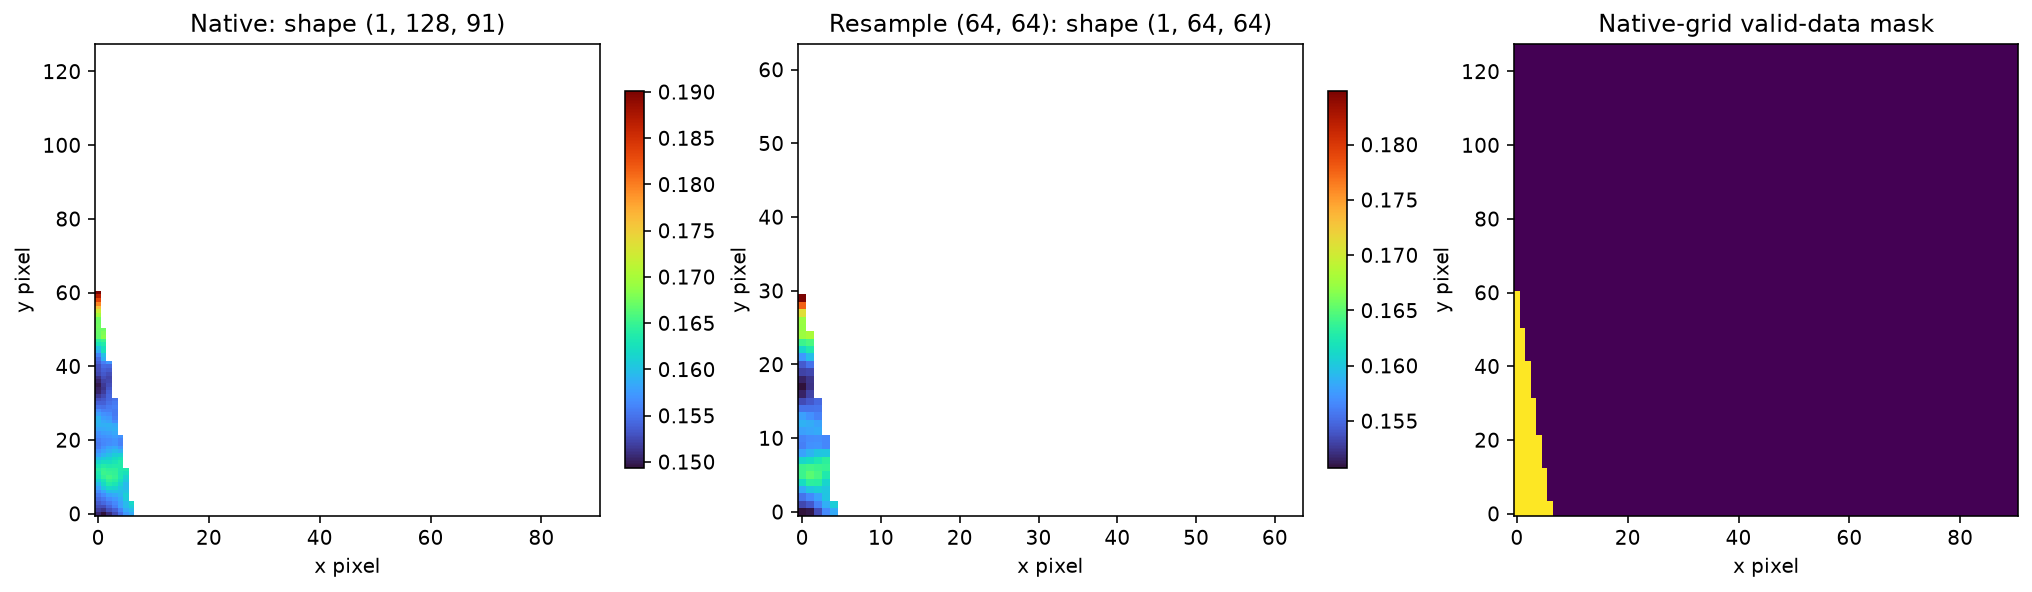

native shape=(1, 128, 91); resampled shape=(1, 64, 64)
Native keeps whatever the source stored, so shapes vary between rows; Resample fixes them at the cost of interpolation.


In [13]:
import matplotlib.pyplot as plt
from ocean_taco.render import Native
native_dataset = OceanTACODataset(queries=recipe_draw, sources={"l3_swot": Native()}, catalog_config=config)
native_record = native_dataset[0]["l3_swot"]
native_data = np.asarray(native_record["data"])
fixed_data = np.asarray(recipe_sample["l3_swot"]["data"])
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
show_grid(axes[0], native_record, "Native")
show_grid(axes[1], recipe_sample["l3_swot"], "Resample (64, 64)")
axes[2].imshow(np.asarray(native_record["valid_mask"])[0], origin="lower", cmap="viridis", vmin=0, vmax=1, aspect="auto")
axes[2].set(title="Native-grid valid-data mask", xlabel="x pixel", ylabel="y pixel")
display_figure(fig)
print(f"native shape={native_data.shape}; resampled shape={fixed_data.shape}")
print("Native keeps whatever the source stored, so shapes vary between rows; Resample fixes them at the cost of interpolation.")

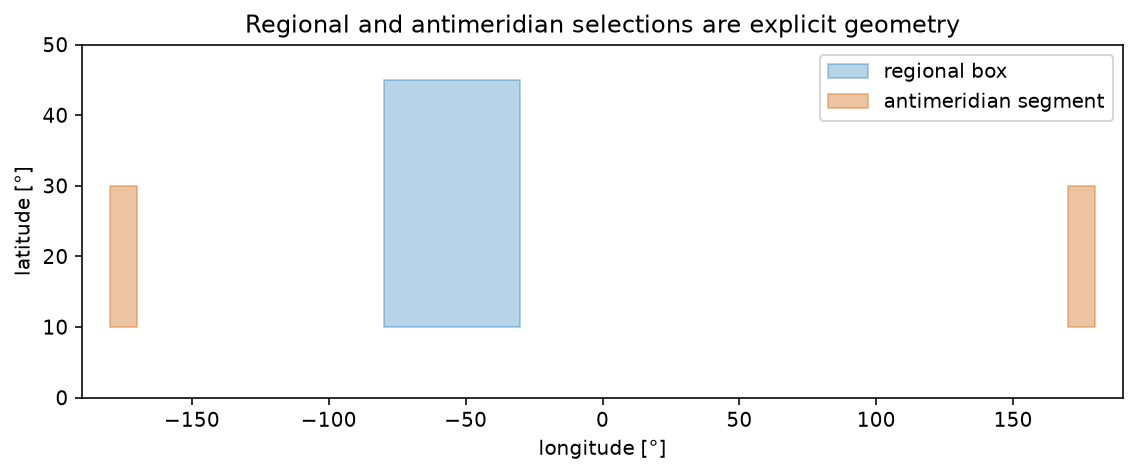

Regional bounds, wrapped bounds, and validity-aware normalisation are all explicit configuration choices.


In [14]:
import matplotlib.pyplot as plt
fig, axis = plt.subplots(figsize=(8, 3.4))
axis.fill_between([-80, -30], 10, 45, alpha=.35, color="#3182bd", label="regional box")
for segment in wrapped.segments():
    axis.fill_between([segment.lon_min, segment.lon_max], segment.lat_min, segment.lat_max, alpha=.5, color="#dd8a45", label="antimeridian segment")
axis.set(xlim=(-190, 190), ylim=(0, 50), xlabel="longitude [°]", ylabel="latitude [°]", title="Regional and antimeridian selections are explicit geometry")
handles, labels = axis.get_legend_handles_labels()
axis.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys())
fig.tight_layout()
from IPython.display import display
display_figure(fig)
print("Regional bounds, wrapped bounds, and validity-aware normalisation are all explicit configuration choices.")